# 딥러닝 실습 - 퍼셉트론에서 MLP까지


## 학습 목표

1. **생물학적 뉴런**과 **인공 뉴런**의 관계를 이해함
2. **퍼셉트론**으로 논리 게이트(AND, OR, NOT)를 구현함
3. **XOR 문제**와 단일 퍼셉트론의 한계를 파악함
4. **다층 퍼셉트론(MLP)**의 등장 배경과 구조를 이해함
5. **순전파**와 **역전파**의 개념을 직관적으로 이해함

### 1.1 생물학적 뉴런 vs 인공 뉴런

| 생물학적 뉴런 | 인공 뉴런 | 역할 |
|:---:|:---:|:---|
| 수상돌기 (Dendrites) | 입력 $x_i$ | 외부에서 정보 수신 |
| 시냅스 강도 | 가중치 $w_i$ | 연결의 중요도 결정 |
| 세포체 (Soma) | 가중합 $\sum$ | 입력 정보 통합 |
| 역치 (Threshold) | 편향 $b$ | 발화 기준 설정 |
| 활동 전위 발생 | 활성화 함수 $f$ | 출력 여부 결정 |
| 축삭 출력 | 출력 $y$ | 다음 단계로 신호 전달 |

### 1.2 퍼셉트론의 수학적 정의

1958년 **프랭크 로젠블랫(Frank Rosenblatt)** 이 생물학적 뉴런을 수학적으로 모델링하여 **퍼셉트론(Perceptron)** 을 발명

#### 퍼셉트론 연산 과정

**Step 1: 가중합 계산**

$$z = \sum_{i=1}^{n} w_i x_i + b = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b$$

**Step 2: 활성화 함수 적용**

$$y = f(z)$$

여기서:
- $x_i$: 입력값 (features)
- $w_i$: 가중치 (각 입력의 중요도)
- $b$: 편향 (bias, 발화 기준 조절)
- $f$: 활성화 함수
- $y$: 출력값

#### 계단 함수 (Step Function)

초기 퍼셉트론에서 사용한 가장 단순한 활성화 함수:

$$f(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

**의미**: 가중합이 0보다 크면 "발화" (출력 1), 아니면 "비활성" (출력 0)

In [1]:
# 필요 라이브러리 임포트 및 한글 폰트 설정
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyBboxPatch, FancyArrowPatch
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (Google Colab 및 로컬 환경 호환)
import matplotlib.font_manager as fm

def setup_korean_font():
    """한글 폰트를 설정하는 함수"""
    # 사용 가능한 한글 폰트 목록
    korean_fonts = ['NanumGothic', 'NanumBarunGothic', 'Malgun Gothic', 
                    'AppleGothic', 'DejaVu Sans']
    
    # 시스템에서 사용 가능한 폰트 찾기
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    
    for font in korean_fonts:
        if font in available_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            print(f"한글 폰트 설정 완료: {font}")
            return
    
    # 폰트를 찾지 못한 경우 Colab용 설치 시도
    try:
        import subprocess
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], 
                      capture_output=True, check=True)
        fm._rebuild()
        plt.rcParams['font.family'] = 'NanumGothic'
        plt.rcParams['axes.unicode_minus'] = False
        print("나눔고딕 폰트 설치 및 설정 완료")
    except:
        print("한글 폰트 설정 실패 - 영문으로 표시됩니다.")


# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')

setup_korean_font()

print("라이브러리 및 설정 완료")

한글 폰트 설정 완료: NanumGothic
라이브러리 및 설정 완료


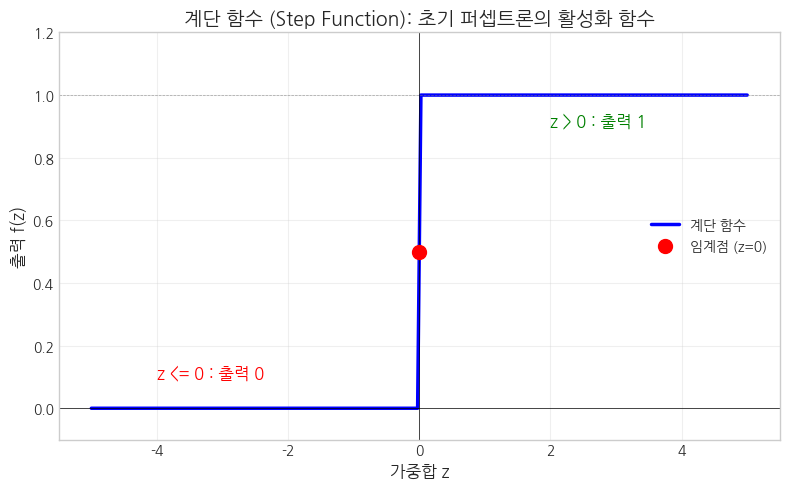


계단 함수의 특성:
- 출력이 0 또는 1로 이산적 (discrete)
- 미분 불가능 (z=0에서 불연속)
- 현대 딥러닝에서는 시그모이드, ReLU 등으로 대체됨


In [2]:
def step_function(z):
    """
    계단 함수 (Step Function)
    
    수학적 정의:
        f(z) = 1  if z > 0
        f(z) = 0  if z <= 0
    
    Parameters:
        z: 가중합 (스칼라 또는 배열)
    
    Returns:
        활성화 출력 (0 또는 1)
    """
    return np.where(z > 0, 1, 0)

# 계단 함수 시각화
z = np.linspace(-5, 5, 200)
y = step_function(z)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(z, y, 'b-', linewidth=2.5, label='계단 함수')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax.axhline(y=1, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)

# 임계점 표시
ax.scatter([0], [0.5], color='red', s=100, zorder=5, label='임계점 (z=0)')
ax.annotate('z > 0 : 출력 1', xy=(2, 0.9), fontsize=12, color='green')
ax.annotate('z <= 0 : 출력 0', xy=(-4, 0.1), fontsize=12, color='red')

ax.set_xlabel('가중합 z', fontsize=12)
ax.set_ylabel('출력 f(z)', fontsize=12)
ax.set_title('계단 함수 (Step Function): 초기 퍼셉트론의 활성화 함수', fontsize=14)
ax.legend(loc='center right')
ax.set_ylim(-0.1, 1.2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n계단 함수의 특성:")
print("- 출력이 0 또는 1로 이산적 (discrete)")
print("- 미분 불가능 (z=0에서 불연속)")
print("- 현대 딥러닝에서는 시그모이드, ReLU 등으로 대체됨")

---

## 실습 1: 범용 신경망 시뮬레이터 모듈

다양한 실험을 효율적으로 수행하기 위해, 학습/시각화/예측을 수행하는 **범용 모듈**을 먼저 정의합니다.

이 모듈의 특징:
- 입력층, 은닉층(0개~N개), 출력층을 자유롭게 구성
- 다양한 활성화 함수 선택 가능 (step, sigmoid, tanh, relu)
- 학습 과정 실시간 시각화
- 결정 경계 자동 시각화

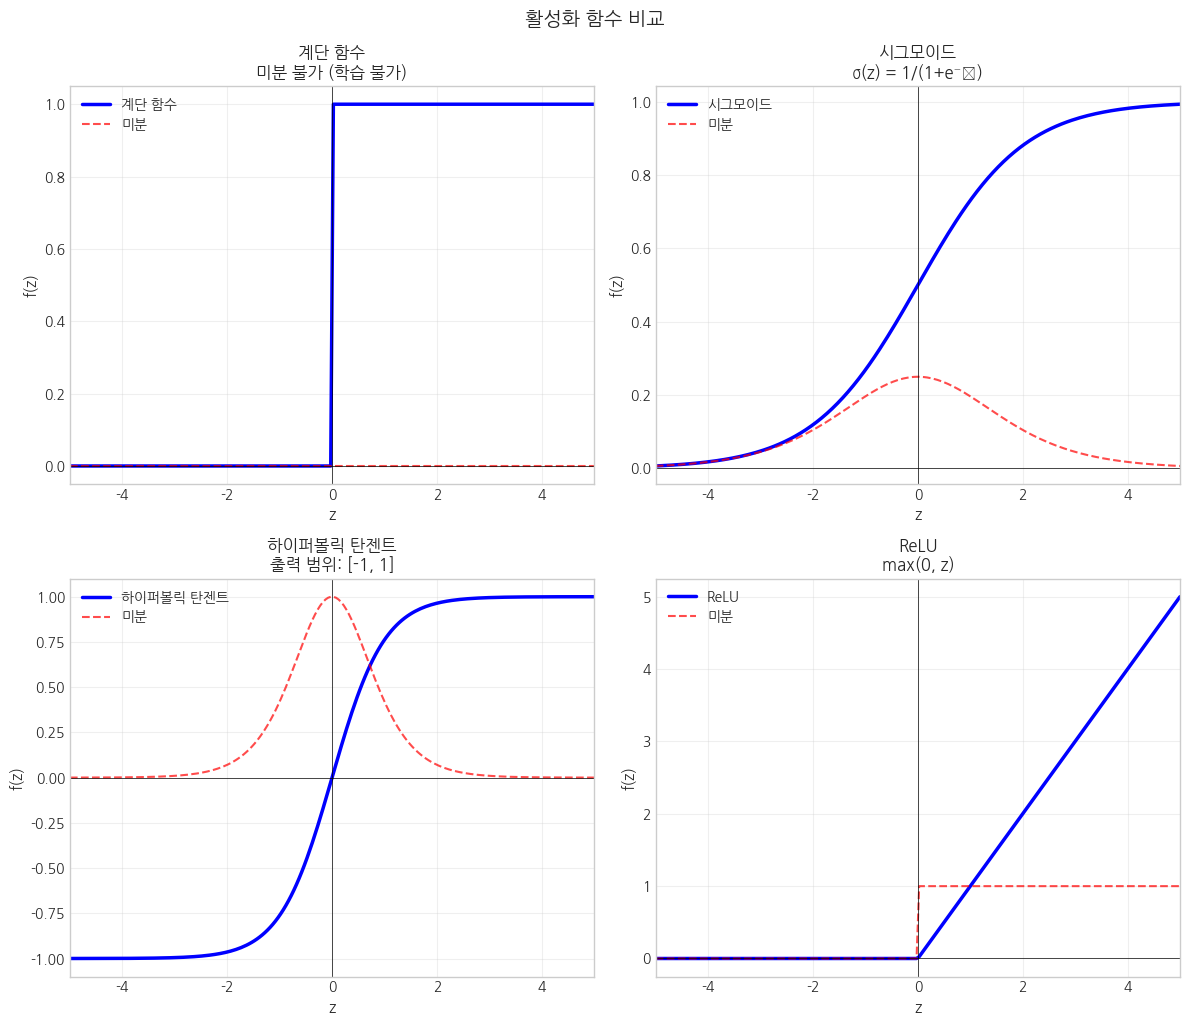


활성화 함수 선택 가이드:
- step: 퍼셉트론 원리 이해용 (학습 불가)
- sigmoid: 출력이 확률처럼 [0,1] 범위가 필요할 때
- tanh: 은닉층에서 많이 사용, 중심이 0
- relu: 현대 딥러닝의 표준, 기울기 소실 문제 완화


In [3]:
# ============================================================
# 범용 신경망 시뮬레이터 모듈
# ============================================================

class ActivationFunctions:
    """
    활성화 함수 모음
    
    각 활성화 함수와 그 미분을 제공합니다.
    학습에는 미분 가능한 함수(sigmoid, tanh, relu)가 필요합니다.
    """
    
    @staticmethod
    def step(z):
        """계단 함수 - 학습 불가, 게이트 시연용"""
        return np.where(z > 0, 1, 0)
    
    @staticmethod
    def step_derivative(z):
        """계단 함수 미분 - 0 (학습 불가)"""
        return np.zeros_like(z)
    
    @staticmethod
    def sigmoid(z):
        """시그모이드 함수: σ(z) = 1 / (1 + e^(-z))"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    @staticmethod
    def sigmoid_derivative(z):
        """시그모이드 미분: σ'(z) = σ(z) * (1 - σ(z))"""
        s = ActivationFunctions.sigmoid(z)
        return s * (1 - s)
    
    @staticmethod
    def tanh(z):
        """하이퍼볼릭 탄젠트: 출력 범위 [-1, 1]"""
        return np.tanh(z)
    
    @staticmethod
    def tanh_derivative(z):
        """tanh 미분: 1 - tanh²(z)"""
        return 1 - np.tanh(z) ** 2
    
    @staticmethod
    def relu(z):
        """ReLU: max(0, z)"""
        return np.maximum(0, z)
    
    @staticmethod
    def relu_derivative(z):
        """ReLU 미분: z > 0이면 1, 아니면 0"""
        return np.where(z > 0, 1, 0)
    
    @staticmethod
    def get(name):
        """이름으로 활성화 함수와 미분 함수 반환"""
        functions = {
            'step': (ActivationFunctions.step, ActivationFunctions.step_derivative),
            'sigmoid': (ActivationFunctions.sigmoid, ActivationFunctions.sigmoid_derivative),
            'tanh': (ActivationFunctions.tanh, ActivationFunctions.tanh_derivative),
            'relu': (ActivationFunctions.relu, ActivationFunctions.relu_derivative)
        }
        return functions.get(name, (ActivationFunctions.sigmoid, ActivationFunctions.sigmoid_derivative))


# 활성화 함수 시각화
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
z = np.linspace(-5, 5, 200)

functions_info = [
    ('step', '계단 함수', '미분 불가 (학습 불가)'),
    ('sigmoid', '시그모이드', 'σ(z) = 1/(1+e⁻ᶻ)'),
    ('tanh', '하이퍼볼릭 탄젠트', '출력 범위: [-1, 1]'),
    ('relu', 'ReLU', 'max(0, z)')
]

for ax, (name, title, desc) in zip(axes.flatten(), functions_info):
    func, deriv = ActivationFunctions.get(name)
    y = func(z)
    dy = deriv(z)
    
    ax.plot(z, y, 'b-', linewidth=2.5, label=f'{title}')
    ax.plot(z, dy, 'r--', linewidth=1.5, alpha=0.7, label='미분')
    ax.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    ax.axvline(x=0, color='k', linestyle='-', linewidth=0.5)
    ax.set_xlabel('z', fontsize=11)
    ax.set_ylabel('f(z)', fontsize=11)
    ax.set_title(f'{title}\n{desc}', fontsize=12)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)

plt.tight_layout()
plt.suptitle('활성화 함수 비교', fontsize=14, y=1.02)
plt.show()

print("\n활성화 함수 선택 가이드:")
print("- step: 퍼셉트론 원리 이해용 (학습 불가)")
print("- sigmoid: 출력이 확률처럼 [0,1] 범위가 필요할 때")
print("- tanh: 은닉층에서 많이 사용, 중심이 0")
print("- relu: 현대 딥러닝의 표준, 기울기 소실 문제 완화")

In [4]:
class NeuralNetworkSimulator:
    """
    범용 다층 퍼셉트론 시뮬레이터
    
    특징:
    - 은닉층 개수와 각 층의 뉴런 수를 자유롭게 설정
    - 다양한 활성화 함수 지원
    - 학습 과정 시각화 기능 내장
    
    Parameters:
    -----------
    layer_sizes : list
        각 층의 뉴런 수. 예: [2, 4, 1] = 입력 2개, 은닉 4개, 출력 1개
    activation : str
        활성화 함수 이름 ('sigmoid', 'tanh', 'relu')
    learning_rate : float
        학습률
    random_seed : int
        재현성을 위한 랜덤 시드
    """
    
    def __init__(self, layer_sizes, activation='sigmoid', learning_rate=0.5, random_seed=42):
        np.random.seed(random_seed)
        
        self.layer_sizes = layer_sizes
        self.n_layers = len(layer_sizes)
        self.lr = learning_rate
        self.activation_name = activation
        self.activation, self.activation_deriv = ActivationFunctions.get(activation)
        
        # 가중치와 편향 초기화 (Xavier 초기화)
        self.weights = []
        self.biases = []
        
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            # Xavier 초기화
            scale = np.sqrt(2.0 / (fan_in + fan_out))
            W = np.random.randn(fan_in, fan_out) * scale
            b = np.zeros((1, fan_out))
            self.weights.append(W)
            self.biases.append(b)
        
        # 학습 기록
        self.losses = []
        self.accuracies = []
        
        # 중간 계산값 저장 (역전파용)
        self.z_values = []  # 가중합
        self.a_values = []  # 활성화 출력
    
    def forward(self, X):
        """
        순전파 (Forward Propagation)
        
        각 층에서의 계산:
            z = X @ W + b  (가중합)
            a = f(z)       (활성화)
        """
        self.z_values = []
        self.a_values = [X]  # 입력층도 저장
        
        current_input = X
        for i in range(len(self.weights)):
            z = current_input @ self.weights[i] + self.biases[i]
            a = self.activation(z)
            
            self.z_values.append(z)
            self.a_values.append(a)
            current_input = a
        
        return current_input
    
    def compute_loss(self, y_true, y_pred):
        """평균 제곱 오차 (MSE) 계산"""
        return np.mean((y_true - y_pred) ** 2)
    
    def backward(self, X, y_true):
        """
        역전파 (Backpropagation)
        
        연쇄 법칙을 사용하여 각 가중치의 기울기 계산
        """
        m = X.shape[0]  # 샘플 수
        
        # 출력층 오차
        y_pred = self.a_values[-1]
        delta = -(y_true - y_pred) * self.activation_deriv(self.z_values[-1])
        
        # 각 층의 기울기 저장
        weight_grads = []
        bias_grads = []
        
        # 출력층부터 역순으로
        for i in range(len(self.weights) - 1, -1, -1):
            # 기울기 계산
            dW = self.a_values[i].T @ delta / m
            db = np.mean(delta, axis=0, keepdims=True)
            
            weight_grads.insert(0, dW)
            bias_grads.insert(0, db)
            
            # 이전 층으로 오차 전파 (첫 번째 층 제외)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self.activation_deriv(self.z_values[i-1])
        
        # 가중치 업데이트
        for i in range(len(self.weights)):
            self.weights[i] -= self.lr * weight_grads[i]
            self.biases[i] -= self.lr * bias_grads[i]
    
    def train(self, X, y, epochs=1000, print_every=100, verbose=True):
        """
        모델 학습
        
        Parameters:
        -----------
        X : ndarray
            입력 데이터
        y : ndarray
            정답 레이블
        epochs : int
            학습 반복 횟수
        print_every : int
            출력 주기
        
        Returns:
        --------
        losses : list
            학습 과정의 손실값 기록
        """
        self.losses = []
        self.accuracies = []
        
        for epoch in range(epochs):
            # 순전파
            y_pred = self.forward(X)
            
            # 손실 계산
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)
            
            # 정확도 계산
            predictions = (y_pred > 0.5).astype(int)
            accuracy = np.mean(predictions == y) * 100
            self.accuracies.append(accuracy)
            
            # 역전파
            self.backward(X, y)
            
            # 진행 상황 출력
            if verbose and (epoch % print_every == 0 or epoch == epochs - 1):
                print(f"Epoch {epoch:4d}/{epochs} | 손실: {loss:.6f} | 정확도: {accuracy:.1f}%")
        
        return self.losses
    
    def predict(self, X, threshold=0.5):
        """예측 (이진 분류)"""
        y_prob = self.forward(X)
        return (y_prob > threshold).astype(int)
    
    def predict_proba(self, X):
        """확률 예측"""
        return self.forward(X)
    
    def get_architecture_string(self):
        """네트워크 구조 문자열 반환"""
        return ' → '.join([str(s) for s in self.layer_sizes])
    
    def summary(self):
        """모델 요약 정보 출력"""
        print("=" * 50)
        print("신경망 구조 요약")
        print("=" * 50)
        print(f"구조: {self.get_architecture_string()}")
        print(f"활성화 함수: {self.activation_name}")
        print(f"학습률: {self.lr}")
        print("-" * 50)
        
        total_params = 0
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            n_params = W.size + b.size
            total_params += n_params
            print(f"층 {i+1}: {W.shape[0]} -> {W.shape[1]} (파라미터: {n_params})")
        
        print("-" * 50)
        print(f"총 파라미터 수: {total_params}")
        print("=" * 50)

print("NeuralNetworkSimulator 클래스 정의 완료")

NeuralNetworkSimulator 클래스 정의 완료


In [5]:
class Visualizer:
    """
    신경망 시각화 도구 모음
    
    제공 기능:
    - 학습 곡선 시각화
    - 결정 경계 시각화
    - 네트워크 구조 다이어그램
    - 가중치 히트맵
    """
    
    @staticmethod
    def plot_learning_curve(model, figsize=(12, 4)):
        """
        학습 곡선 시각화 (손실 + 정확도)
        """
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # 손실 곡선
        ax = axes[0]
        ax.plot(model.losses, 'b-', linewidth=1.5, alpha=0.8)
        ax.set_xlabel('에포크', fontsize=11)
        ax.set_ylabel('손실 (MSE)', fontsize=11)
        ax.set_title(f'학습 곡선 - {model.get_architecture_string()}', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        # 정확도 곡선
        ax = axes[1]
        ax.plot(model.accuracies, 'g-', linewidth=1.5, alpha=0.8)
        ax.set_xlabel('에포크', fontsize=11)
        ax.set_ylabel('정확도 (%)', fontsize=11)
        ax.set_title('정확도 변화', fontsize=12)
        ax.set_ylim(0, 105)
        ax.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='목표: 100%')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        return fig
    
    @staticmethod
    def plot_decision_boundary(model, X, y, title=None, figsize=(8, 6), resolution=100):
        """
        2D 입력에 대한 결정 경계 시각화
        
        Parameters:
        -----------
        model : NeuralNetworkSimulator
            학습된 모델
        X : ndarray
            입력 데이터 (N, 2)
        y : ndarray
            정답 레이블
        title : str
            그래프 제목
        """
        if X.shape[1] != 2:
            print("결정 경계 시각화는 2차원 입력만 지원합니다.")
            return None
        
        fig, ax = plt.subplots(figsize=figsize)
        
        # 결정 영역 그리기
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        
        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, resolution),
            np.linspace(y_min, y_max, resolution)
        )
        
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict_proba(grid_points)
        Z = Z.reshape(xx.shape)
        
        # 결정 경계 컨투어
        cmap_bg = ListedColormap(['#ffcccc', '#ccffcc'])
        ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], cmap=cmap_bg, alpha=0.4)
        ax.contour(xx, yy, Z, levels=[0.5], colors='blue', linewidths=2, linestyles='--')
        
        # 데이터 포인트 표시
        for label in [0, 1]:
            mask = (y.flatten() == label)
            color = 'red' if label == 0 else 'green'
            marker = 's' if label == 0 else 'o'
            ax.scatter(X[mask, 0], X[mask, 1], c=color, marker=marker, 
                      s=150, edgecolor='black', linewidth=1.5, 
                      label=f'클래스 {label}', zorder=5)
        
        # 각 데이터 포인트에 좌표 표시
        for i, (x1, x2) in enumerate(X):
            ax.annotate(f'({x1:.0f},{x2:.0f})', (x1+0.08, x2+0.08), fontsize=10)
        
        ax.set_xlabel('$x_1$', fontsize=12)
        ax.set_ylabel('$x_2$', fontsize=12)
        
        if title is None:
            title = f'결정 경계 - {model.get_architecture_string()}'
        ax.set_title(title, fontsize=13)
        
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal', adjustable='box')
        
        plt.tight_layout()
        return fig
    
    @staticmethod
    def plot_network_diagram(layer_sizes, title="네트워크 구조", figsize=(10, 6)):
        """
        신경망 구조 다이어그램 시각화
        """
        fig, ax = plt.subplots(figsize=figsize)
        
        n_layers = len(layer_sizes)
        max_neurons = max(layer_sizes)
        
        # 레이어 위치 계산
        layer_x = np.linspace(0, 1, n_layers)
        
        neuron_positions = []
        
        # 뉴런 그리기
        for i, (x, n_neurons) in enumerate(zip(layer_x, layer_sizes)):
            positions = []
            
            # 뉴런 y 위치 (중앙 정렬)
            if n_neurons == 1:
                y_positions = [0.5]
            else:
                y_positions = np.linspace(0.2, 0.8, n_neurons)
            
            for j, y in enumerate(y_positions):
                positions.append((x, y))
                
                # 뉴런 색상
                if i == 0:
                    color = '#a8d5ba'  # 입력층 - 연두색
                elif i == n_layers - 1:
                    color = '#f4a261'  # 출력층 - 주황색
                else:
                    color = '#b8d4e3'  # 은닉층 - 하늘색
                
                circle = plt.Circle((x, y), 0.035, color=color, ec='black', linewidth=1.5, zorder=3)
                ax.add_patch(circle)
            
            neuron_positions.append(positions)
            
            # 레이어 레이블
            if i == 0:
                label = f'입력층\n({n_neurons})'
            elif i == n_layers - 1:
                label = f'출력층\n({n_neurons})'
            else:
                label = f'은닉층 {i}\n({n_neurons})'
            
            ax.text(x, 0.02, label, ha='center', va='top', fontsize=10, fontweight='bold')
        
        # 연결선 그리기
        for i in range(len(neuron_positions) - 1):
            for pos1 in neuron_positions[i]:
                for pos2 in neuron_positions[i + 1]:
                    ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], 
                           'gray', linewidth=0.5, alpha=0.5, zorder=1)
        
        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.05, 1.0)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
        
        plt.tight_layout()
        return fig
    
    @staticmethod
    def plot_comparison(results_dict, title="모델 비교", figsize=(14, 5)):
        """
        여러 모델의 학습 결과 비교
        
        Parameters:
        -----------
        results_dict : dict
            {모델명: (losses, accuracies)} 형태의 딕셔너리
        """
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        colors = plt.cm.tab10(np.linspace(0, 1, len(results_dict)))
        
        for (name, (losses, accuracies)), color in zip(results_dict.items(), colors):
            # 손실 곡선
            axes[0].plot(losses, color=color, linewidth=1.5, label=name, alpha=0.8)
            # 정확도 곡선
            axes[1].plot(accuracies, color=color, linewidth=1.5, label=name, alpha=0.8)
        
        axes[0].set_xlabel('에포크', fontsize=11)
        axes[0].set_ylabel('손실 (MSE)', fontsize=11)
        axes[0].set_title('손실 비교', fontsize=12)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        axes[1].set_xlabel('에포크', fontsize=11)
        axes[1].set_ylabel('정확도 (%)', fontsize=11)
        axes[1].set_title('정확도 비교', fontsize=12)
        axes[1].legend()
        axes[1].set_ylim(0, 105)
        axes[1].grid(True, alpha=0.3)
        
        plt.suptitle(title, fontsize=14, fontweight='bold')
        plt.tight_layout()
        return fig

print("Visualizer 클래스 정의 완료")

Visualizer 클래스 정의 완료


---

## 실습 2: 퍼셉트론으로 논리 게이트 구현하기

### 2.1 논리 게이트란?

디지털 회로의 기본 구성 요소로, 입력에 따라 특정 논리 연산을 수행함.

| 게이트 | 의미 | 실생활 예시 |
|:---:|:---|:---|
| AND | 둘 다 참이면 참 | 비밀번호 **그리고** 지문이 일치해야 잠금 해제 |
| OR | 하나라도 참이면 참 | 화재경보 **또는** 침입경보가 울리면 대피 |
| NOT | 반전 | 스위치가 꺼져있으면 켜기 |
| NAND | AND의 부정 | 범용 게이트 (모든 논리 구현 가능) |

In [6]:
class LogicGates:
    """
    퍼셉트론으로 구현한 논리 게이트 모음
    
    각 게이트는 수동으로 설정된 가중치와 편향을 사용합니다.
    이를 통해 퍼셉트론의 동작 원리를 직관적으로 이해할 수 있습니다.
    """
    
    @staticmethod
    def AND(x1, x2, verbose=False):
        """
        AND 게이트: 둘 다 1이어야 출력 1
        
        결정 경계: 0.5*x1 + 0.5*x2 - 0.7 = 0
                   x1 + x2 = 1.4
        """
        w1, w2, b = 0.5, 0.5, -0.7
        z = w1 * x1 + w2 * x2 + b
        result = 1 if z > 0 else 0
        if verbose:
            print(f"AND({x1}, {x2}): z = {w1}*{x1} + {w2}*{x2} + {b} = {z:.2f} → {result}")
        return result
    
    @staticmethod
    def OR(x1, x2, verbose=False):
        """
        OR 게이트: 하나라도 1이면 출력 1
        
        결정 경계: 0.5*x1 + 0.5*x2 - 0.2 = 0
                   x1 + x2 = 0.4
        """
        w1, w2, b = 0.5, 0.5, -0.2
        z = w1 * x1 + w2 * x2 + b
        result = 1 if z > 0 else 0
        if verbose:
            print(f"OR({x1}, {x2}): z = {w1}*{x1} + {w2}*{x2} + {b} = {z:.2f} → {result}")
        return result
    
    @staticmethod
    def NAND(x1, x2, verbose=False):
        """
        NAND 게이트: AND의 반대
        
        결정 경계: -0.5*x1 - 0.5*x2 + 0.7 = 0
        """
        w1, w2, b = -0.5, -0.5, 0.7
        z = w1 * x1 + w2 * x2 + b
        result = 1 if z > 0 else 0
        if verbose:
            print(f"NAND({x1}, {x2}): z = {w1}*{x1} + {w2}*{x2} + {b} = {z:.2f} → {result}")
        return result
    
    @staticmethod
    def NOR(x1, x2, verbose=False):
        """
        NOR 게이트: OR의 반대
        
        결정 경계: -0.5*x1 - 0.5*x2 + 0.2 = 0
        """
        w1, w2, b = -0.5, -0.5, 0.2
        z = w1 * x1 + w2 * x2 + b
        result = 1 if z > 0 else 0
        if verbose:
            print(f"NOR({x1}, {x2}): z = {w1}*{x1} + {w2}*{x2} + {b} = {z:.2f} → {result}")
        return result
    
    @staticmethod
    def NOT(x, verbose=False):
        """
        NOT 게이트: 입력 반전
        """
        w, b = -1.0, 0.5
        z = w * x + b
        result = 1 if z > 0 else 0
        if verbose:
            print(f"NOT({x}): z = {w}*{x} + {b} = {z:.2f} → {result}")
        return result
    
    @staticmethod
    def XOR_MLP(x1, x2, verbose=False):
        """
        XOR을 다층 퍼셉트론으로 구현
        
        구조: NAND + OR -> AND
        XOR(x1, x2) = AND(NAND(x1, x2), OR(x1, x2))
        """
        h1 = LogicGates.NAND(x1, x2)  # 은닉 뉴런 1
        h2 = LogicGates.OR(x1, x2)    # 은닉 뉴런 2
        y = LogicGates.AND(h1, h2)    # 출력 뉴런
        
        if verbose:
            print(f"XOR({x1}, {x2}):")
            print(f"  은닉층: NAND={h1}, OR={h2}")
            print(f"  출력층: AND({h1}, {h2}) = {y}")
        
        return y
    
    @staticmethod
    def print_truth_table(gate_name, gate_func, two_inputs=True):
        """진리표 출력"""
        print(f"\n[{gate_name} 게이트 진리표]")
        print("-" * 30)
        
        if two_inputs:
            print(f"{'x1':^8}{'x2':^8}{gate_name:^10}")
            print("-" * 30)
            for x1 in [0, 1]:
                for x2 in [0, 1]:
                    result = gate_func(x1, x2)
                    print(f"{x1:^8}{x2:^8}{result:^10}")
        else:
            print(f"{'x':^12}{gate_name:^12}")
            print("-" * 30)
            for x in [0, 1]:
                result = gate_func(x)
                print(f"{x:^12}{result:^12}")


# 진리표 출력
print("=" * 60)
print("퍼셉트론으로 구현한 논리 게이트 진리표")
print("=" * 60)

LogicGates.print_truth_table("AND", LogicGates.AND)
LogicGates.print_truth_table("OR", LogicGates.OR)
LogicGates.print_truth_table("NAND", LogicGates.NAND)
LogicGates.print_truth_table("NOR", LogicGates.NOR)
LogicGates.print_truth_table("NOT", LogicGates.NOT, two_inputs=False)

퍼셉트론으로 구현한 논리 게이트 진리표

[AND 게이트 진리표]
------------------------------
   x1      x2      AND    
------------------------------
   0       0        0     
   0       1        0     
   1       0        0     
   1       1        1     

[OR 게이트 진리표]
------------------------------
   x1      x2       OR    
------------------------------
   0       0        0     
   0       1        1     
   1       0        1     
   1       1        1     

[NAND 게이트 진리표]
------------------------------
   x1      x2      NAND   
------------------------------
   0       0        1     
   0       1        1     
   1       0        1     
   1       1        0     

[NOR 게이트 진리표]
------------------------------
   x1      x2      NOR    
------------------------------
   0       0        1     
   0       1        0     
   1       0        0     
   1       1        0     

[NOT 게이트 진리표]
------------------------------
     x          NOT     
------------------------------
     0           1      
   

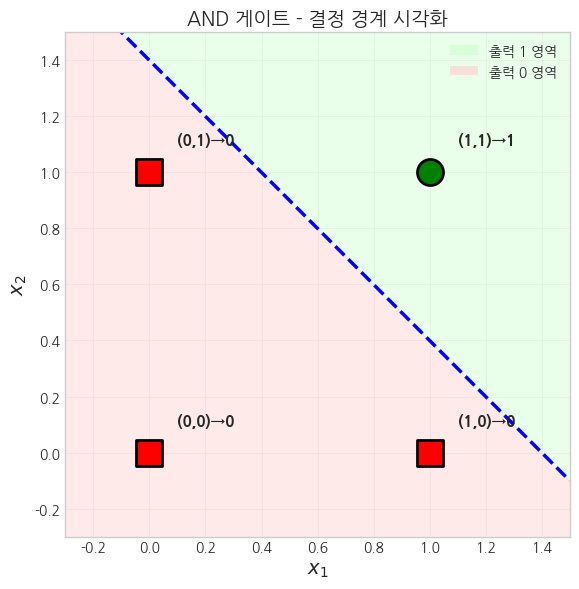

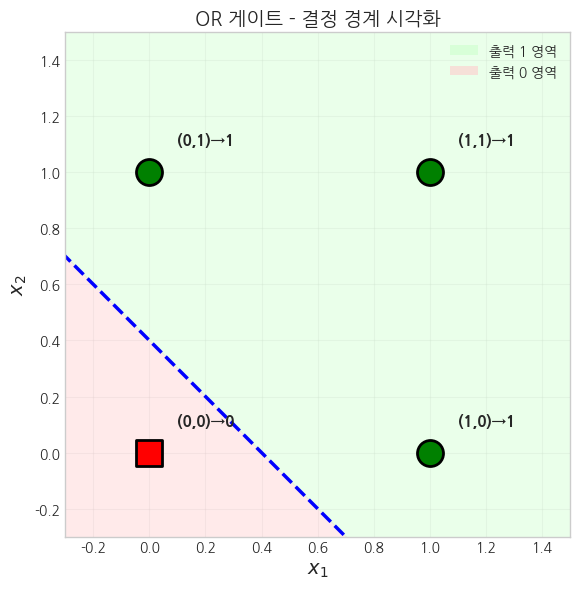


핵심 관찰:
- AND, OR 게이트는 모두 직선 하나로 0과 1을 분리 가능
- 이를 '선형 분리 가능(Linearly Separable)'이라 함
- 단일 퍼셉트론은 선형 분리 가능한 문제만 해결 가능


In [7]:
def visualize_gate_decision_boundary(gate_func, gate_name, w1, w2, b):
    """
    논리 게이트의 결정 경계를 시각화
    
    결정 경계: w1*x1 + w2*x2 + b = 0
    """
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # 결정 영역 색상
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200),
                         np.linspace(-0.5, 1.5, 200))
    Z = np.array([[gate_func(x, y) for x, y in zip(row_x, row_y)]
                  for row_x, row_y in zip(xx, yy)])
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5],
                colors=['#ffcccc', '#ccffcc'], alpha=0.4)
    
    # 결정 경계선
    if w2 != 0:
        x_line = np.linspace(-0.5, 1.5, 100)
        y_line = -(w1 * x_line + b) / w2
        ax.plot(x_line, y_line, 'b--', linewidth=2.5, 
                label=f'결정 경계: {w1}$x_1$+{w2}$x_2$+({b})=0')
    
    # 데이터 포인트
    points = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for x1, x2 in points:
        result = gate_func(x1, x2)
        color = 'green' if result == 1 else 'red'
        marker = 'o' if result == 1 else 's'
        ax.scatter(x1, x2, c=color, s=350, marker=marker,
                   edgecolor='black', linewidth=2, zorder=5)
        ax.annotate(f'({x1},{x2})→{result}', (x1+0.1, x2+0.1), 
                   fontsize=11, fontweight='bold')
    
    ax.set_xlim(-0.3, 1.5)
    ax.set_ylim(-0.3, 1.5)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title(f'{gate_name} 게이트 - 결정 경계 시각화', fontsize=14)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 범례 추가
    legend_elements = [
        Patch(facecolor='#ccffcc', alpha=0.6, label='출력 1 영역'),
        Patch(facecolor='#ffcccc', alpha=0.6, label='출력 0 영역')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    return fig

# AND, OR 게이트 결정 경계 시각화
fig1 = visualize_gate_decision_boundary(LogicGates.AND, 'AND', 0.5, 0.5, -0.7)
plt.show()

fig2 = visualize_gate_decision_boundary(LogicGates.OR, 'OR', 0.5, 0.5, -0.2)
plt.show()

print("\n핵심 관찰:")
print("- AND, OR 게이트는 모두 직선 하나로 0과 1을 분리 가능")
print("- 이를 '선형 분리 가능(Linearly Separable)'이라 함")
print("- 단일 퍼셉트론은 선형 분리 가능한 문제만 해결 가능")

---

## 실습 3: XOR 문제 - 퍼셉트론의 한계

### 3.1 XOR 게이트란?

**논리적 의미**: "$x_1$과 $x_2$가 **서로 다르면** 참"

| $x_1$ | $x_2$ | XOR |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | **1** |
| 1 | 0 | **1** |
| 1 | 1 | 0 |

**실생활 예시**:
- 계단 양쪽 스위치: 한쪽만 누르면 불이 켜짐, 둘 다 누르면 꺼짐
- "둘 중 하나만 선택" 상황

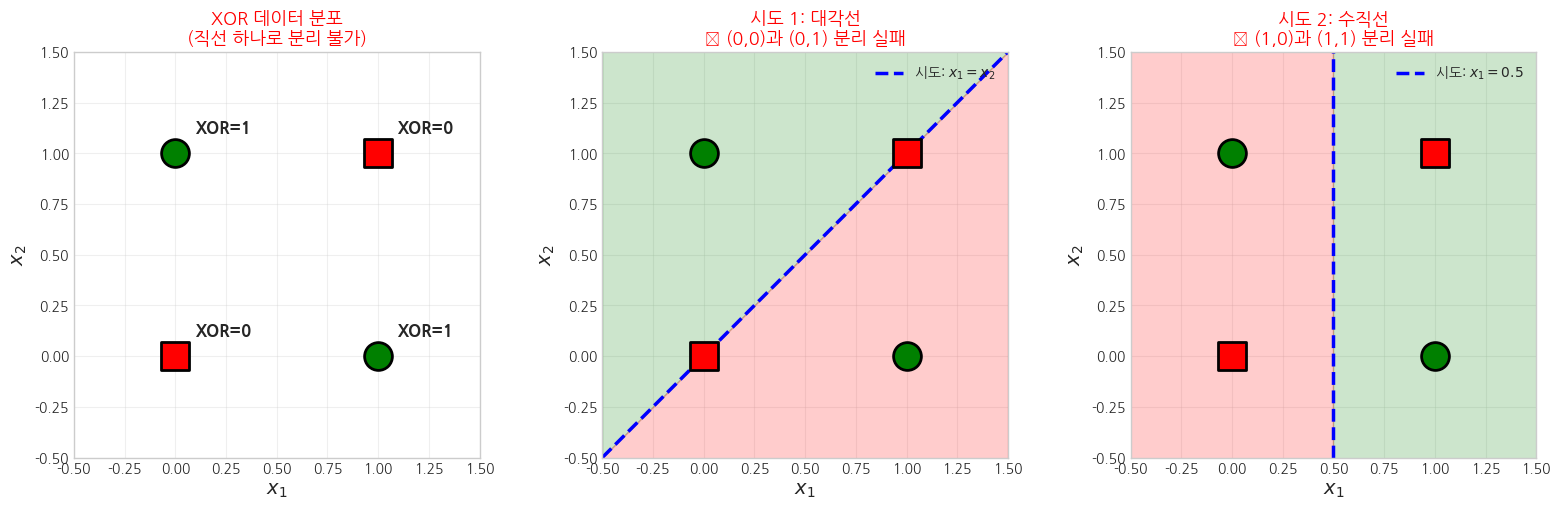


결론: XOR은 어떤 직선으로도 두 클래스를 분리할 수 없음
→ 이를 '선형 분리 불가능(Linearly Inseparable)' 문제라 함
→ 단일 퍼셉트론의 근본적 한계!


In [8]:
def visualize_xor_problem():
    """
    XOR 문제가 왜 선형 분리 불가능한지 시각화
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # XOR 데이터
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor = np.array([0, 1, 1, 0])
    colors = ['red' if label == 0 else 'green' for label in y_xor]
    markers = ['s' if label == 0 else 'o' for label in y_xor]
    
    # 그래프 1: XOR 데이터 분포
    ax = axes[0]
    for i, (x, label) in enumerate(zip(X, y_xor)):
        ax.scatter(x[0], x[1], c=colors[i], s=400, marker=markers[i],
                   edgecolor='black', linewidth=2, zorder=5)
        ax.annotate(f'XOR={label}', (x[0]+0.1, x[1]+0.1), fontsize=12, fontweight='bold')
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title('XOR 데이터 분포\n(직선 하나로 분리 불가)', fontsize=13, color='red')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 그래프 2: 시도 1 - 대각선
    ax = axes[1]
    for i, (x, label) in enumerate(zip(X, y_xor)):
        ax.scatter(x[0], x[1], c=colors[i], s=400, marker=markers[i],
                   edgecolor='black', linewidth=2, zorder=5)
    
    x_line = np.linspace(-0.5, 1.5, 100)
    ax.plot(x_line, x_line, 'b--', linewidth=2.5, label='시도: $x_1 = x_2$')
    ax.fill_between(x_line, x_line, 2, alpha=0.2, color='green')
    ax.fill_between(x_line, -1, x_line, alpha=0.2, color='red')
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title('시도 1: 대각선\n❌ (0,0)과 (0,1) 분리 실패', fontsize=13, color='red')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 그래프 3: 시도 2 - 수직선
    ax = axes[2]
    for i, (x, label) in enumerate(zip(X, y_xor)):
        ax.scatter(x[0], x[1], c=colors[i], s=400, marker=markers[i],
                   edgecolor='black', linewidth=2, zorder=5)
    
    ax.axvline(x=0.5, color='b', linestyle='--', linewidth=2.5, label='시도: $x_1 = 0.5$')
    ax.fill_betweenx([-1, 2], 0.5, 2, alpha=0.2, color='green')
    ax.fill_betweenx([-1, 2], -1, 0.5, alpha=0.2, color='red')
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title('시도 2: 수직선\n❌ (1,0)과 (1,1) 분리 실패', fontsize=13, color='red')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

fig = visualize_xor_problem()
plt.show()

print("\n결론: XOR은 어떤 직선으로도 두 클래스를 분리할 수 없음")
print("→ 이를 '선형 분리 불가능(Linearly Inseparable)' 문제라 함")
print("→ 단일 퍼셉트론의 근본적 한계!")

### 3.2 역사적 맥락: AI 겨울의 시작

**1969년, Marvin Minsky와 Seymour Papert**의 저서 "Perceptrons"에서 단일 퍼셉트론의 한계를 수학적으로 증명함.

> "퍼셉트론은 XOR과 같은 **선형 분리 불가능한 문제**를 풀 수 없다."

**파급 효과**:
- 신경망 연구에 대한 회의론 급증
- 연구 자금 대폭 삭감
- 약 15~20년간 **"AI 겨울"** (AI Winter) 시작

**해결책**: 층을 쌓자! (다층 퍼셉트론의 등장)

---

## 실습 4: 다층 퍼셉트론(MLP)의 등장

### 4.1 핵심 아이디어: 중간 단계(은닉층) 추가

| 구조 | 설명 | XOR 해결 |
|:---:|:---|:---:|
| 단일 퍼셉트론 | 입력 → 출력 | ❌ |
| **다층 퍼셉트론** | 입력 → 은닉층 → 출력 | ✅ |

### 4.2 XOR의 논리적 분해

XOR은 AND, OR, NAND의 조합으로 표현 가능:

$$\text{XOR}(x_1, x_2) = \text{AND}(\text{NAND}(x_1, x_2), \text{OR}(x_1, x_2))$$

| $x_1$ | $x_2$ | NAND | OR | AND(NAND, OR) |
|:---:|:---:|:---:|:---:|:---:|
| 0 | 0 | 1 | 0 | **0** |
| 0 | 1 | 1 | 1 | **1** |
| 1 | 0 | 1 | 1 | **1** |
| 1 | 1 | 0 | 1 | **0** |

XOR 다층 퍼셉트론 (수동 구현) 진리표
  x1     x2    NAND(h1)    OR(h2)    XOR(출력)  
------------------------------------------------------------
  0      0        1          0          0     
  0      1        1          1          1     
  1      0        1          1          1     
  1      1        0          1          0     

성공! 다층 퍼셉트론으로 XOR 문제 해결!


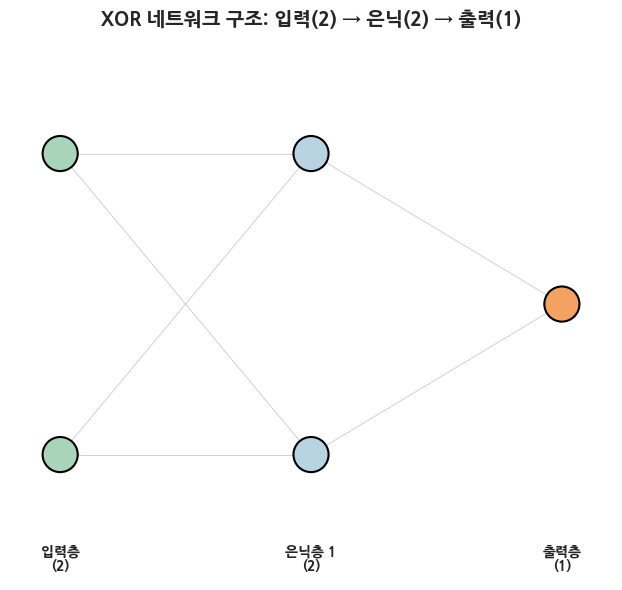

In [9]:
# XOR 네트워크 (수동 구현) 테스트
print("=" * 60)
print("XOR 다층 퍼셉트론 (수동 구현) 진리표")
print("=" * 60)
print(f"{'x1':^6} {'x2':^6} {'NAND(h1)':^10} {'OR(h2)':^10} {'XOR(출력)':^10}")
print("-" * 60)

for x1 in [0, 1]:
    for x2 in [0, 1]:
        h1 = LogicGates.NAND(x1, x2)
        h2 = LogicGates.OR(x1, x2)
        y = LogicGates.XOR_MLP(x1, x2)
        print(f"{x1:^6} {x2:^6} {h1:^10} {h2:^10} {y:^10}")

print("\n성공! 다층 퍼셉트론으로 XOR 문제 해결!")

# 네트워크 구조 시각화
fig = Visualizer.plot_network_diagram([2, 2, 1], "XOR 네트워크 구조: 입력(2) → 은닉(2) → 출력(1)")
plt.show()

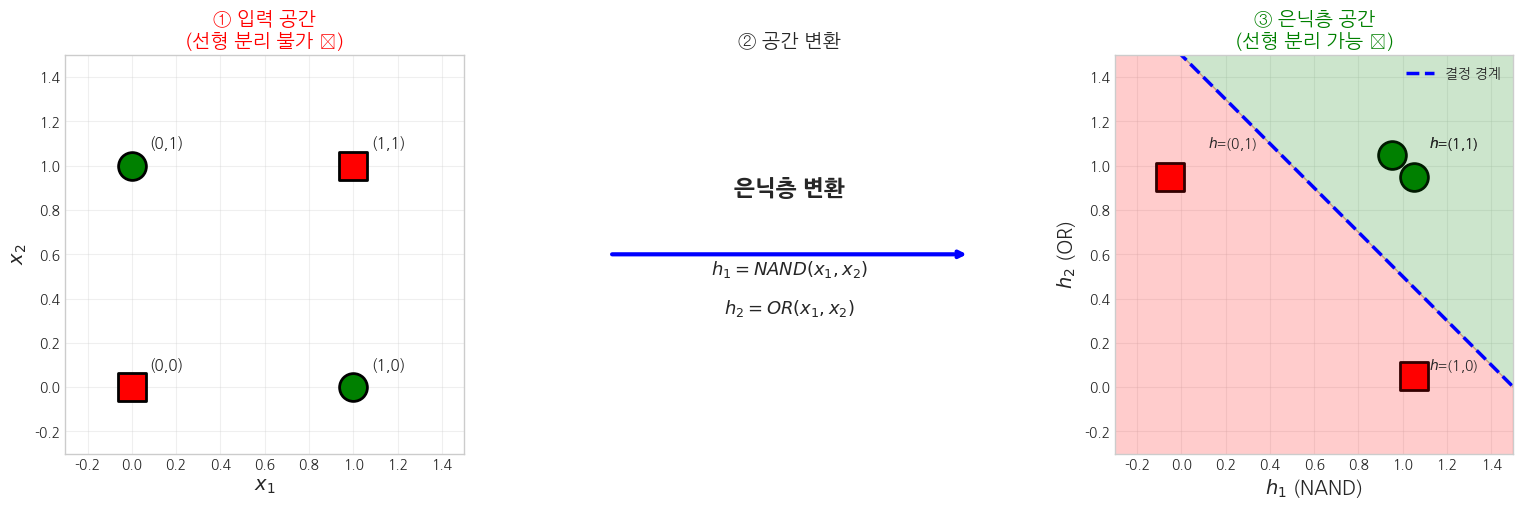


핵심 통찰:
- 은닉층은 입력 데이터를 새로운 공간으로 '변환'하는 역할
- 변환된 공간에서는 복잡한 문제도 선형 분리 가능해질 수 있음
- 층이 많을수록 더 복잡한 변환 = 더 복잡한 문제 해결 가능


In [10]:
def visualize_space_transformation():
    """
    은닉층이 공간을 어떻게 변환하는지 시각화
    
    핵심 아이디어:
    - 원래 공간에서 선형 분리 불가능한 데이터를
    - 은닉층을 통해 새로운 공간으로 변환하면
    - 선형 분리 가능해짐!
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # 원래 입력
    X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
    y_xor = np.array([0, 1, 1, 0])
    
    # 은닉층 출력 계산
    H = []
    for x1, x2 in X:
        h1 = LogicGates.NAND(x1, x2)
        h2 = LogicGates.OR(x1, x2)
        H.append([h1, h2])
    H = np.array(H)
    
    colors = ['red' if label == 0 else 'green' for label in y_xor]
    markers = ['s' if label == 0 else 'o' for label in y_xor]
    
    # 그래프 1: 입력 공간
    ax = axes[0]
    for i, (x, label) in enumerate(zip(X, y_xor)):
        ax.scatter(x[0], x[1], c=colors[i], s=400, marker=markers[i],
                   edgecolor='black', linewidth=2)
        ax.annotate(f'({x[0]},{x[1]})', (x[0]+0.08, x[1]+0.08), fontsize=11)
    ax.set_xlabel('$x_1$', fontsize=14)
    ax.set_ylabel('$x_2$', fontsize=14)
    ax.set_title('① 입력 공간\n(선형 분리 불가 ❌)', fontsize=14, color='red')
    ax.set_xlim(-0.3, 1.5)
    ax.set_ylim(-0.3, 1.5)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    # 그래프 2: 변환 설명
    ax = axes[1]
    ax.text(0.5, 0.65, '은닉층 변환', fontsize=16, ha='center', fontweight='bold')
    ax.text(0.5, 0.45, '$h_1 = NAND(x_1, x_2)$', fontsize=13, ha='center', family='monospace')
    ax.text(0.5, 0.35, '$h_2 = OR(x_1, x_2)$', fontsize=13, ha='center', family='monospace')
    
    # 화살표
    ax.annotate('', xy=(0.9, 0.5), xytext=(0.1, 0.5),
                arrowprops=dict(arrowstyle='->', lw=3, color='blue'))
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('② 공간 변환', fontsize=14)
    
    # 그래프 3: 은닉층 출력 공간
    ax = axes[2]
    for i, (h, label) in enumerate(zip(H, y_xor)):
        # 약간의 오프셋 추가 (겹치는 점 구분)
        offset_x = 0.05 if i % 2 == 0 else -0.05
        offset_y = 0.05 if i < 2 else -0.05
        ax.scatter(h[0] + offset_x, h[1] + offset_y, c=colors[i], s=400, marker=markers[i],
                   edgecolor='black', linewidth=2)
        ax.annotate(f'$h$=({h[0]},{h[1]})', (h[0]+0.12, h[1]+0.08), fontsize=10)
    
    # 결정 경계 (h1 + h2 = 1.5)
    h_line = np.linspace(-0.3, 1.5, 100)
    ax.plot(h_line, 1.5 - h_line, 'b--', linewidth=2.5, label='결정 경계')
    ax.fill_between(h_line, 1.5 - h_line, 2, alpha=0.2, color='green')
    ax.fill_between(h_line, -1, 1.5 - h_line, alpha=0.2, color='red')
    
    ax.set_xlabel('$h_1$ (NAND)', fontsize=14)
    ax.set_ylabel('$h_2$ (OR)', fontsize=14)
    ax.set_title('③ 은닉층 공간\n(선형 분리 가능 ✅)', fontsize=14, color='green')
    ax.set_xlim(-0.3, 1.5)
    ax.set_ylim(-0.3, 1.5)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    plt.tight_layout()
    return fig

fig = visualize_space_transformation()
plt.show()

print("\n핵심 통찰:")
print("- 은닉층은 입력 데이터를 새로운 공간으로 '변환'하는 역할")
print("- 변환된 공간에서는 복잡한 문제도 선형 분리 가능해질 수 있음")
print("- 층이 많을수록 더 복잡한 변환 = 더 복잡한 문제 해결 가능")

---

## 실습 5: 학습을 통한 XOR 해결

### 5.1 순전파 (Forward Propagation)

**정의**: 입력에서 출력 방향으로 데이터가 흐르며 계산되는 과정

#### 2층 MLP의 순전파 수식

**Step 1: 은닉층 계산**

$$z^{(1)} = W^{(1)} x + b^{(1)} \quad\quad h = f(z^{(1)})$$

**Step 2: 출력층 계산**

$$z^{(2)} = W^{(2)} h + b^{(2)} \quad\quad \hat{y} = f(z^{(2)})$$

**Step 3: 손실 계산 (MSE)**

$$L = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### 5.2 역전파 (Backpropagation)

**정의**: 손실을 출력에서 입력 방향으로 전파하여 각 가중치의 기울기를 계산하는 과정

#### 핵심: 연쇄 법칙 (Chain Rule)

합성 함수의 미분:

$$\frac{d}{dx} f(g(x)) = f'(g(x)) \cdot g'(x)$$

신경망에서:

$$\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial h} \cdot \frac{\partial h}{\partial w_1}$$

**비유**: 도미노 효과
- $w_1$이 바뀌면 $h$가 바뀌고, $y$가 바뀌고, $L$이 바뀜
- 각 단계의 변화량을 곱해서 전체 영향 계산

In [11]:
# XOR 학습 실행
print("=" * 60)
print("XOR 문제 학습 (순전파 + 역전파)")
print("=" * 60)

# XOR 데이터
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

# MLP 생성 (입력 2 -> 은닉 4 -> 출력 1)
xor_model = NeuralNetworkSimulator(
    layer_sizes=[2, 4, 1],
    activation='sigmoid',
    learning_rate=2.0,
    random_seed=42
)

# 모델 요약
xor_model.summary()

# 학습 전 예측
print("\n학습 전 예측:")
y_pred_before = xor_model.forward(X_xor)
for i in range(4):
    print(f"XOR({X_xor[i,0]}, {X_xor[i,1]}) = {y_pred_before[i,0]:.4f} (정답: {y_xor[i,0]})")

XOR 문제 학습 (순전파 + 역전파)
신경망 구조 요약
구조: 2 → 4 → 1
활성화 함수: sigmoid
학습률: 2.0
--------------------------------------------------
층 1: 2 -> 4 (파라미터: 12)
층 2: 4 -> 1 (파라미터: 5)
--------------------------------------------------
총 파라미터 수: 17

학습 전 예측:
XOR(0, 0) = 0.4327 (정답: 0)
XOR(0, 1) = 0.4093 (정답: 1)
XOR(1, 0) = 0.4045 (정답: 1)
XOR(1, 1) = 0.3849 (정답: 0)


In [12]:
# 학습 진행
print("\n" + "=" * 60)
print("학습 시작")
print("=" * 60)

losses = xor_model.train(X_xor, y_xor, epochs=2000, print_every=400)

# 학습 후 예측
print("\n" + "-" * 40)
print("학습 후 예측:")
print("-" * 40)
y_pred_after = xor_model.forward(X_xor)
for i in range(4):
    pred = y_pred_after[i, 0]
    pred_class = 1 if pred > 0.5 else 0
    status = "✓" if pred_class == y_xor[i, 0] else "✗"
    print(f"XOR({X_xor[i,0]}, {X_xor[i,1]}) = {pred:.4f} → {pred_class} {status}")


학습 시작
Epoch    0/2000 | 손실: 0.259741 | 정확도: 50.0%
Epoch  400/2000 | 손실: 0.249529 | 정확도: 50.0%
Epoch  800/2000 | 손실: 0.216965 | 정확도: 75.0%
Epoch 1200/2000 | 손실: 0.058794 | 정확도: 100.0%
Epoch 1600/2000 | 손실: 0.009651 | 정확도: 100.0%
Epoch 1999/2000 | 손실: 0.004223 | 정확도: 100.0%

----------------------------------------
학습 후 예측:
----------------------------------------
XOR(0, 0) = 0.0690 → 0 ✓
XOR(0, 1) = 0.9385 → 1 ✓
XOR(1, 0) = 0.9378 → 1 ✓
XOR(1, 1) = 0.0667 → 0 ✓


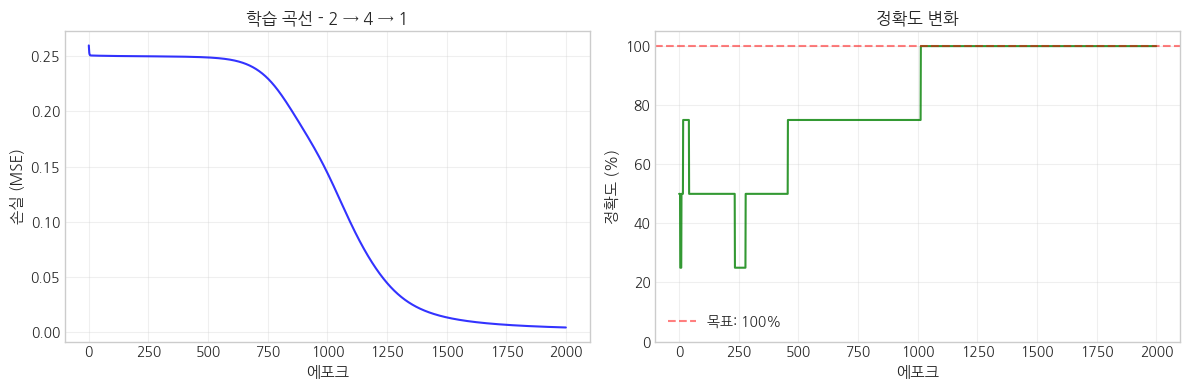

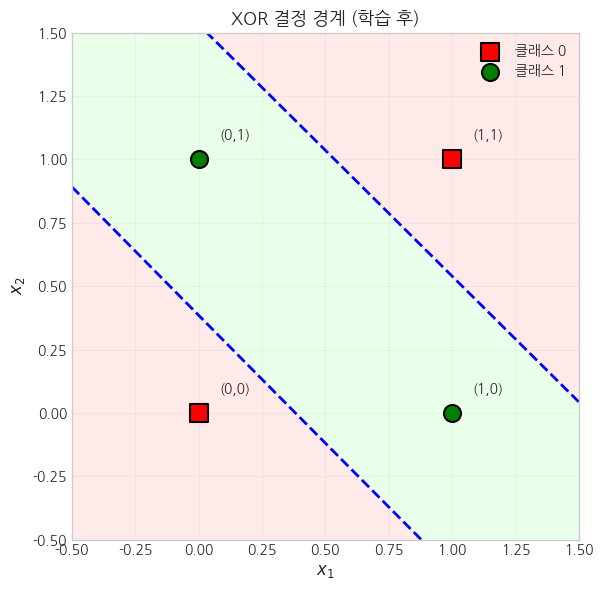


학습 결과 요약:
- 초기 손실: 0.259741
- 최종 손실: 0.004223
- 개선율: 98.37%


In [13]:
# 학습 결과 시각화
fig1 = Visualizer.plot_learning_curve(xor_model)
plt.show()

fig2 = Visualizer.plot_decision_boundary(xor_model, X_xor, y_xor, "XOR 결정 경계 (학습 후)")
plt.show()

print(f"\n학습 결과 요약:")
print(f"- 초기 손실: {losses[0]:.6f}")
print(f"- 최종 손실: {losses[-1]:.6f}")
print(f"- 개선율: {(1 - losses[-1]/losses[0])*100:.2f}%")

---

## 실습 6: 네트워크 구조 실험

은닉층의 뉴런 수와 층 수가 학습에 미치는 영향을 실험합니다.

**실험 설계**:
1. 은닉층 없음 (단일 퍼셉트론): [2, 1]
2. 은닉층 2개: [2, 2, 1]
3. 은닉층 4개: [2, 4, 1]
4. 은닉층 8개: [2, 8, 1]
5. 2개 은닉층: [2, 4, 2, 1]

In [14]:
def run_architecture_experiment(X, y, architectures, epochs=2000, lr=2.0):
    """
    여러 네트워크 구조에 대한 비교 실험 수행
    
    Parameters:
    -----------
    X : ndarray
        입력 데이터
    y : ndarray
        정답 레이블
    architectures : list
        테스트할 구조 목록. 예: [[2,1], [2,4,1], [2,4,2,1]]
    
    Returns:
    --------
    results : dict
        {구조명: (losses, accuracies, model)}
    """
    results = {}
    
    for arch in architectures:
        name = ' → '.join([str(s) for s in arch])
        print(f"\n{'='*50}")
        print(f"구조: {name}")
        print(f"{'='*50}")
        
        model = NeuralNetworkSimulator(
            layer_sizes=arch,
            activation='sigmoid',
            learning_rate=lr,
            random_seed=42
        )
        
        losses = model.train(X, y, epochs=epochs, print_every=epochs, verbose=False)
        
        final_acc = model.accuracies[-1]
        print(f"최종 손실: {losses[-1]:.6f}")
        print(f"최종 정확도: {final_acc:.1f}%")
        
        results[name] = (model.losses, model.accuracies, model)
    
    return results

# 실험 실행
architectures_to_test = [
    [2, 1],        # 은닉층 없음
    [2, 2, 1],     # 은닉층 2개
    [2, 4, 1],     # 은닉층 4개
    [2, 8, 1],     # 은닉층 8개
    [2, 4, 2, 1],  # 2개 은닉층
]

experiment_results = run_architecture_experiment(
    X_xor, y_xor, 
    architectures_to_test,
    epochs=2000,
    lr=2.0
)


구조: 2 → 1
최종 손실: 0.250000
최종 정확도: 50.0%

구조: 2 → 2 → 1
최종 손실: 0.129922
최종 정확도: 50.0%

구조: 2 → 4 → 1
최종 손실: 0.004223
최종 정확도: 100.0%

구조: 2 → 8 → 1
최종 손실: 0.002278
최종 정확도: 100.0%

구조: 2 → 4 → 2 → 1
최종 손실: 0.001862
최종 정확도: 100.0%


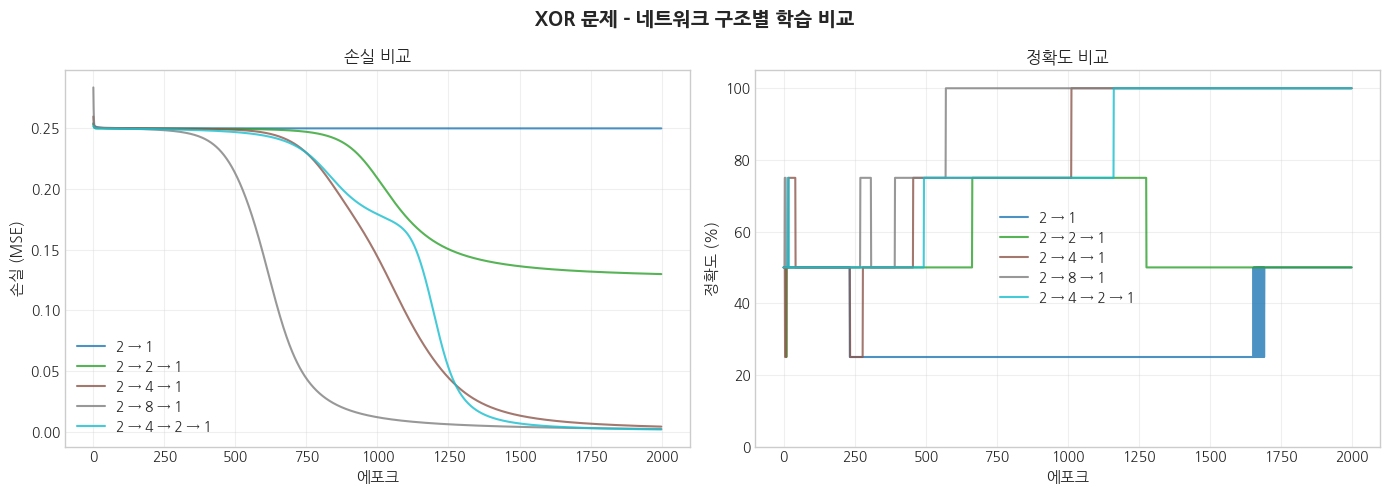


실험 결과 요약
구조                             최종 손실          최종 정확도       XOR 해결
----------------------------------------------------------------------
2 → 1                       0.250000           50.0%            ✗
2 → 2 → 1                   0.129922           50.0%            ✗
2 → 4 → 1                   0.004223          100.0%            ✓
2 → 8 → 1                   0.002278          100.0%            ✓
2 → 4 → 2 → 1               0.001862          100.0%            ✓

핵심 관찰:
- 은닉층이 없는 [2,1] 구조는 XOR을 해결할 수 없음 (선형 분리 한계)
- 은닉층이 있으면 XOR 해결 가능
- 은닉 뉴런 수가 너무 적으면 학습이 느리거나 불완전할 수 있음
- 적절한 구조 선택이 중요!


In [15]:
# 비교 결과 시각화
comparison_data = {name: (losses, accs) for name, (losses, accs, _) in experiment_results.items()}
fig = Visualizer.plot_comparison(comparison_data, "XOR 문제 - 네트워크 구조별 학습 비교")
plt.show()

# 결과 요약
print("\n" + "=" * 70)
print("실험 결과 요약")
print("=" * 70)
print(f"{'구조':<20} {'최종 손실':>15} {'최종 정확도':>15} {'XOR 해결':>12}")
print("-" * 70)

for name, (losses, accs, model) in experiment_results.items():
    solved = "✓" if accs[-1] == 100 else "✗"
    print(f"{name:<20} {losses[-1]:>15.6f} {accs[-1]:>14.1f}% {solved:>12}")

print("\n핵심 관찰:")
print("- 은닉층이 없는 [2,1] 구조는 XOR을 해결할 수 없음 (선형 분리 한계)")
print("- 은닉층이 있으면 XOR 해결 가능")
print("- 은닉 뉴런 수가 너무 적으면 학습이 느리거나 불완전할 수 있음")
print("- 적절한 구조 선택이 중요!")

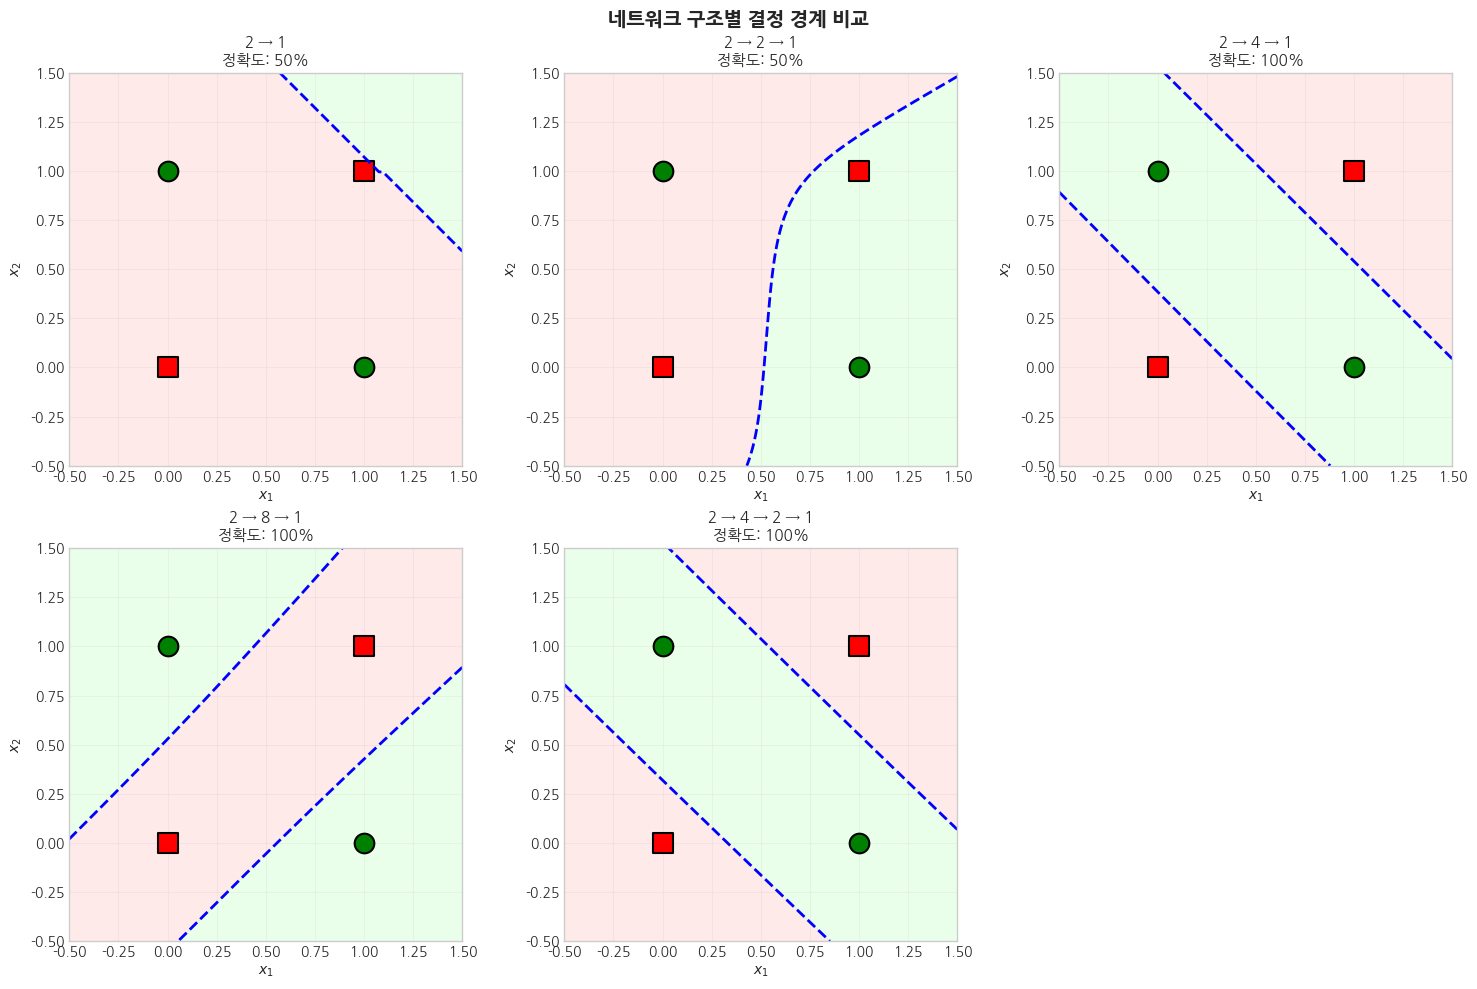

In [16]:
# 각 구조의 결정 경계 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, (_, _, model)) in enumerate(experiment_results.items()):
    if idx >= 5:
        break
    
    ax = axes[idx]
    
    # 결정 영역
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100), np.linspace(-0.5, 1.5, 100))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], colors=['#ffcccc', '#ccffcc'], alpha=0.4)
    ax.contour(xx, yy, Z, levels=[0.5], colors='blue', linewidths=2, linestyles='--')
    
    # 데이터 포인트
    for i, (x, label) in enumerate(zip(X_xor, y_xor.flatten())):
        color = 'green' if label == 1 else 'red'
        marker = 'o' if label == 1 else 's'
        ax.scatter(x[0], x[1], c=color, s=200, marker=marker, edgecolor='black', linewidth=1.5)
    
    final_acc = model.accuracies[-1]
    ax.set_title(f'{name}\n정확도: {final_acc:.0f}%', fontsize=11)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

# 빈 subplot 숨기기
axes[5].axis('off')

plt.suptitle('네트워크 구조별 결정 경계 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 실습 7: 학습률과 에포크 영향 분석

학습률(Learning Rate)은 가중치 업데이트의 크기를 결정하는 중요한 하이퍼파라미터입니다.

$$w_{new} = w_{old} - \eta \cdot \frac{\partial L}{\partial w}$$

- **학습률이 너무 작으면**: 수렴이 매우 느림
- **학습률이 너무 크면**: 최적점을 지나쳐버림 (발산 가능)

학습률 비교 실험
학습률 0.1: 최종 손실 = 0.250296, 정확도 = 50.0%
학습률 0.5: 최종 손실 = 0.249616, 정확도 = 50.0%
학습률 1.0: 최종 손실 = 0.229642, 정확도 = 75.0%
학습률 2.0: 최종 손실 = 0.013394, 정확도 = 100.0%
학습률 5.0: 최종 손실 = 0.001061, 정확도 = 100.0%


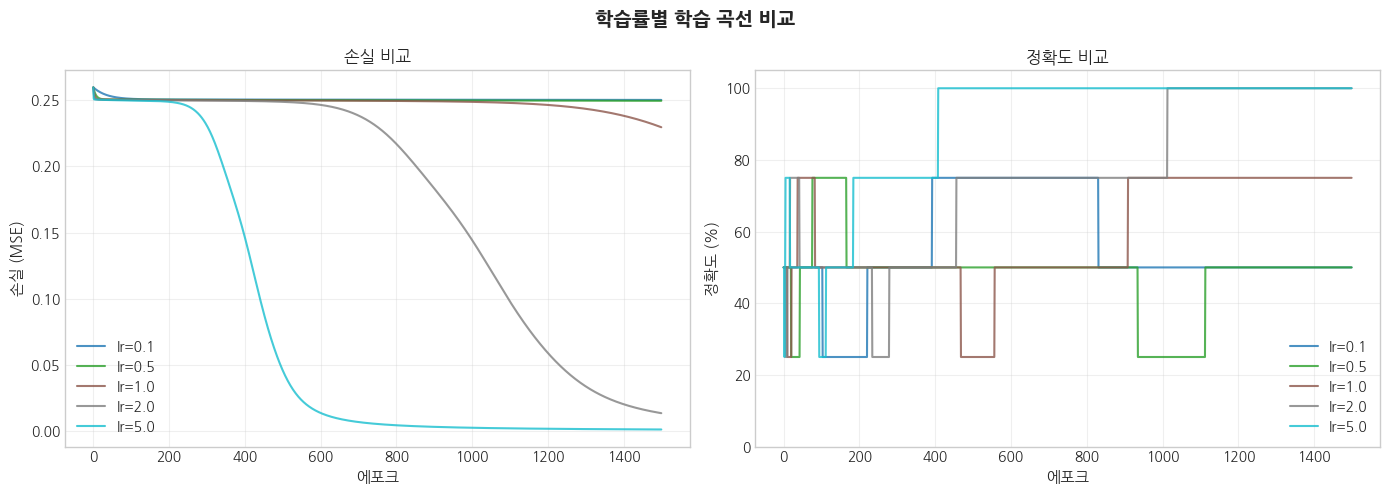


관찰:
- 학습률 0.1: 매우 느린 수렴 (더 많은 에포크 필요)
- 학습률 1.0~2.0: 적절한 수렴 속도
- 학습률 5.0: 불안정할 수 있음 (진동 또는 발산 가능성)


In [17]:
def learning_rate_experiment(X, y, learning_rates, architecture=[2, 4, 1], epochs=1500):
    """
    학습률에 따른 학습 속도 비교 실험
    """
    results = {}
    
    for lr in learning_rates:
        model = NeuralNetworkSimulator(
            layer_sizes=architecture,
            activation='sigmoid',
            learning_rate=lr,
            random_seed=42
        )
        
        model.train(X, y, epochs=epochs, verbose=False)
        results[f'lr={lr}'] = (model.losses, model.accuracies)
        
        print(f"학습률 {lr}: 최종 손실 = {model.losses[-1]:.6f}, 정확도 = {model.accuracies[-1]:.1f}%")
    
    return results

# 학습률 실험
print("=" * 60)
print("학습률 비교 실험")
print("=" * 60)

learning_rates = [0.1, 0.5, 1.0, 2.0, 5.0]
lr_results = learning_rate_experiment(X_xor, y_xor, learning_rates, epochs=1500)

# 시각화
fig = Visualizer.plot_comparison(lr_results, "학습률별 학습 곡선 비교")
plt.show()

print("\n관찰:")
print("- 학습률 0.1: 매우 느린 수렴 (더 많은 에포크 필요)")
print("- 학습률 1.0~2.0: 적절한 수렴 속도")
print("- 학습률 5.0: 불안정할 수 있음 (진동 또는 발산 가능성)")

---

## 실습 8: 제조 공정 품질 예측

**WM-811K 데이터셋**은 반도체 제조 공정에서 수집된 실제 웨이퍼 맵(Wafer Bin Map) 데이터입니다.

| 항목 | 내용 |
|:---:|:---|
| 데이터 수 | 811,457개 웨이퍼 맵 |
| 결함 유형 | Center, Donut, Edge-Loc, Edge-Ring, Loc, Random, Scratch, Near-full, none |
| 출처 | 실제 반도체 제조 현장 |

**제조 현장에서의 활용**:
- 숙련된 공정 엔지니어가 수동으로 분류하던 작업을 자동화
- 결함 패턴 분석을 통해 공정 문제 원인 파악
- 수율 향상 및 비용 절감

In [18]:
# 웨이퍼 결함 분류 시뮬레이션 데이터 생성
print("=" * 60)
print("제조 공정 품질 예측 시뮬레이션")
print("=" * 60)

np.random.seed(42)

# 특성: [중심부 결함 밀도, 가장자리 결함 밀도, 전체 결함 수, 패턴 불규칙도]
n_normal = 100
X_normal = np.random.randn(n_normal, 4) * 0.3 + np.array([0.2, 0.2, 0.1, 0.1])
y_normal = np.zeros((n_normal, 1))

n_defect = 100
X_defect = np.random.randn(n_defect, 4) * 0.4 + np.array([0.7, 0.8, 0.9, 0.6])
y_defect = np.ones((n_defect, 1))

# 데이터 결합 및 셔플
X_wafer = np.vstack([X_normal, X_defect])
y_wafer = np.vstack([y_normal, y_defect])

shuffle_idx = np.random.permutation(len(X_wafer))
X_wafer = X_wafer[shuffle_idx]
y_wafer = y_wafer[shuffle_idx]

# 정규화
X_wafer = (X_wafer - X_wafer.min(axis=0)) / (X_wafer.max(axis=0) - X_wafer.min(axis=0) + 1e-8)

# 훈련/테스트 분리
train_size = 160
X_train, X_test = X_wafer[:train_size], X_wafer[train_size:]
y_train, y_test = y_wafer[:train_size], y_wafer[train_size:]

print(f"\n데이터셋 구성:")
print(f"- 전체 샘플: {len(X_wafer)}개")
print(f"- 훈련 샘플: {len(X_train)}개")
print(f"- 테스트 샘플: {len(X_test)}개")
print(f"- 특성 수: {X_wafer.shape[1]}개")
print(f"  (중심부 결함, 가장자리 결함, 전체 결함, 패턴 불규칙도)")

제조 공정 품질 예측 시뮬레이션

데이터셋 구성:
- 전체 샘플: 200개
- 훈련 샘플: 160개
- 테스트 샘플: 40개
- 특성 수: 4개
  (중심부 결함, 가장자리 결함, 전체 결함, 패턴 불규칙도)


In [19]:
# 웨이퍼 품질 예측 MLP 학습
print("\n" + "=" * 60)
print("MLP 모델 학습 (입력 4 → 은닉 8 → 출력 1)")
print("=" * 60)

wafer_model = NeuralNetworkSimulator(
    layer_sizes=[4, 8, 1],
    activation='sigmoid',
    learning_rate=1.0,
    random_seed=42
)

wafer_model.summary()

# 학습
wafer_model.train(X_train, y_train, epochs=1000, print_every=200)

# 테스트 평가
y_pred_test = wafer_model.predict(X_test)
test_accuracy = np.mean(y_pred_test == y_test) * 100

print(f"\n테스트 정확도: {test_accuracy:.2f}%")


MLP 모델 학습 (입력 4 → 은닉 8 → 출력 1)
신경망 구조 요약
구조: 4 → 8 → 1
활성화 함수: sigmoid
학습률: 1.0
--------------------------------------------------
층 1: 4 -> 8 (파라미터: 40)
층 2: 8 -> 1 (파라미터: 9)
--------------------------------------------------
총 파라미터 수: 49
Epoch    0/1000 | 손실: 0.280283 | 정확도: 53.1%
Epoch  200/1000 | 손실: 0.176321 | 정확도: 91.9%
Epoch  400/1000 | 손실: 0.095951 | 정확도: 95.0%
Epoch  600/1000 | 손실: 0.064394 | 정확도: 95.6%
Epoch  800/1000 | 손실: 0.051936 | 정확도: 95.0%
Epoch  999/1000 | 손실: 0.045743 | 정확도: 95.0%

테스트 정확도: 92.50%


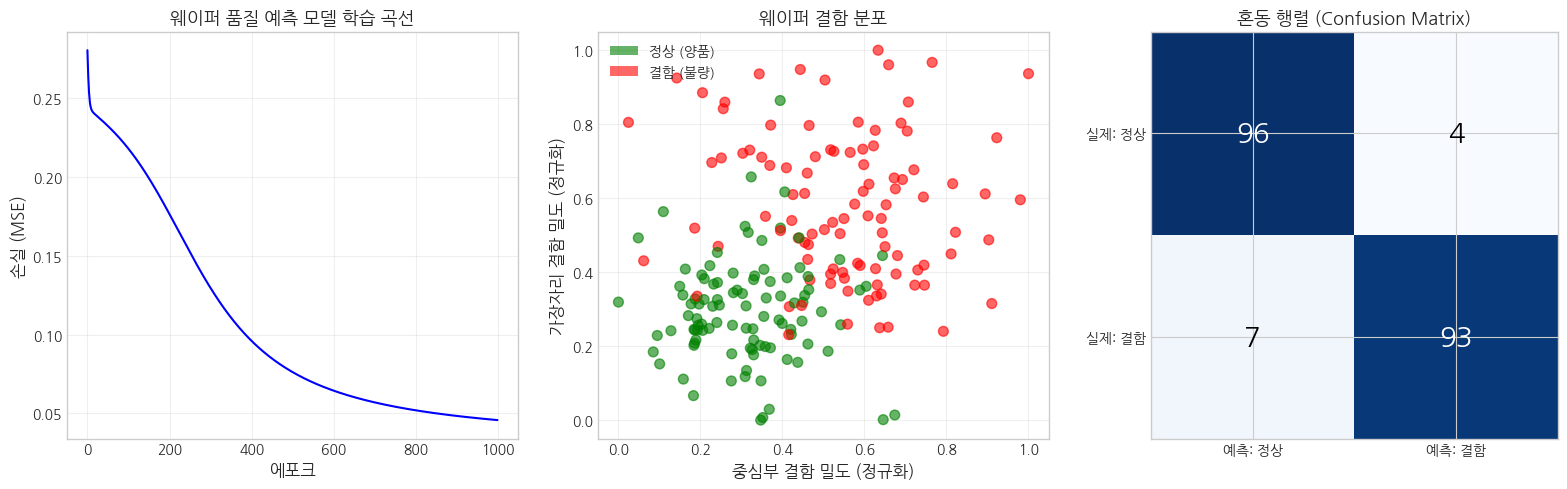


성능 지표:
----------------------------------------
정확도 (Accuracy):  94.50%
정밀도 (Precision): 95.88%
재현율 (Recall):    93.00%
F1 점수:            94.42%


In [20]:
# 결과 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 그래프 1: 학습 곡선
ax = axes[0]
ax.plot(wafer_model.losses, 'b-', linewidth=1.5)
ax.set_xlabel('에포크', fontsize=12)
ax.set_ylabel('손실 (MSE)', fontsize=12)
ax.set_title('웨이퍼 품질 예측 모델 학습 곡선', fontsize=13)
ax.grid(True, alpha=0.3)

# 그래프 2: 특성 분포 (중심부 vs 가장자리 결함 밀도)
ax = axes[1]
colors = ['green' if y == 0 else 'red' for y in y_wafer.flatten()]
ax.scatter(X_wafer[:, 0], X_wafer[:, 1], c=colors, alpha=0.6, s=50)
ax.set_xlabel('중심부 결함 밀도 (정규화)', fontsize=12)
ax.set_ylabel('가장자리 결함 밀도 (정규화)', fontsize=12)
ax.set_title('웨이퍼 결함 분포', fontsize=13)
ax.grid(True, alpha=0.3)

legend_elements = [Patch(facecolor='green', alpha=0.6, label='정상 (양품)'),
                   Patch(facecolor='red', alpha=0.6, label='결함 (불량)')]
ax.legend(handles=legend_elements, loc='upper left')

# 그래프 3: 혼동 행렬
ax = axes[2]

y_pred_all = wafer_model.predict(X_wafer)
tp = np.sum((y_pred_all == 1) & (y_wafer == 1))
tn = np.sum((y_pred_all == 0) & (y_wafer == 0))
fp = np.sum((y_pred_all == 1) & (y_wafer == 0))
fn = np.sum((y_pred_all == 0) & (y_wafer == 1))

cm = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(cm, cmap='Blues')

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]}', ha='center', va='center', 
                fontsize=20, color='white' if cm[i, j] > 50 else 'black')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['예측: 정상', '예측: 결함'])
ax.set_yticklabels(['실제: 정상', '실제: 결함'])
ax.set_title('혼동 행렬 (Confusion Matrix)', fontsize=13)

plt.tight_layout()
plt.show()

# 성능 지표 계산
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("\n성능 지표:")
print("-" * 40)
print(f"정확도 (Accuracy):  {(tp+tn)/(tp+tn+fp+fn)*100:.2f}%")
print(f"정밀도 (Precision): {precision*100:.2f}%")
print(f"재현율 (Recall):    {recall*100:.2f}%")
print(f"F1 점수:            {f1*100:.2f}%")

자유 실험
신경망 구조 요약
구조: 2 → 4 → 1
활성화 함수: sigmoid
학습률: 2.0
--------------------------------------------------
층 1: 2 -> 4 (파라미터: 12)
층 2: 4 -> 1 (파라미터: 5)
--------------------------------------------------
총 파라미터 수: 17
Epoch    0/2000 | 손실: 0.259741 | 정확도: 50.0%
Epoch  400/2000 | 손실: 0.249529 | 정확도: 50.0%
Epoch  800/2000 | 손실: 0.216965 | 정확도: 75.0%
Epoch 1200/2000 | 손실: 0.058794 | 정확도: 100.0%
Epoch 1600/2000 | 손실: 0.009651 | 정확도: 100.0%
Epoch 1999/2000 | 손실: 0.004223 | 정확도: 100.0%


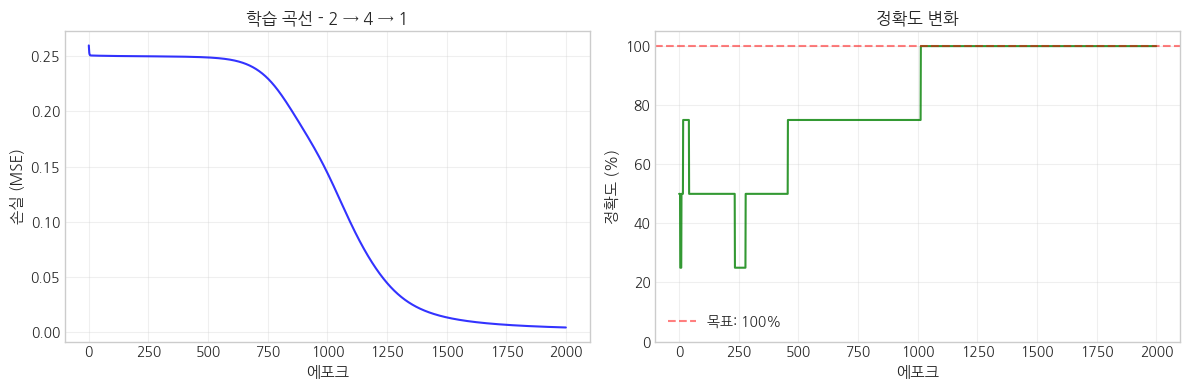

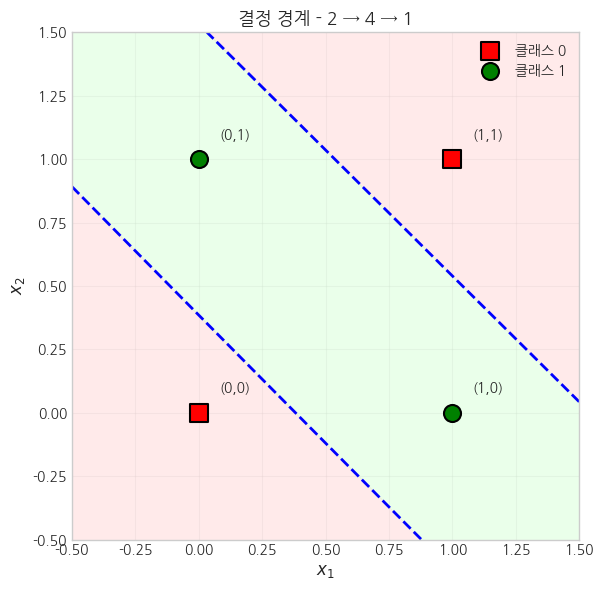

In [21]:
# ============================================================
# 자유 실험 코드
# 아래 파라미터를 변경하여 다양한 실험을 진행해 보세요!
# ============================================================

# 실험 파라미터 (자유롭게 수정하세요)
ARCHITECTURE = [2, 4, 1]      # 네트워크 구조: [입력, 은닉1, 은닉2, ..., 출력]
ACTIVATION = 'sigmoid'        # 활성화 함수: 'sigmoid', 'tanh', 'relu'
LEARNING_RATE = 2.0           # 학습률: 0.1 ~ 10.0 사이 추천
EPOCHS = 2000                 # 학습 반복 횟수

# 데이터 선택 (XOR 또는 다른 데이터)
X_exp = X_xor
y_exp = y_xor

# 모델 생성 및 학습
print("=" * 60)
print("자유 실험")
print("=" * 60)

experiment_model = NeuralNetworkSimulator(
    layer_sizes=ARCHITECTURE,
    activation=ACTIVATION,
    learning_rate=LEARNING_RATE,
    random_seed=42
)

experiment_model.summary()

# 학습
experiment_model.train(X_exp, y_exp, epochs=EPOCHS, print_every=EPOCHS//5)

# 결과 시각화
fig1 = Visualizer.plot_learning_curve(experiment_model)
plt.show()

if X_exp.shape[1] == 2:  # 2D 입력인 경우에만 결정 경계 시각화
    fig2 = Visualizer.plot_decision_boundary(experiment_model, X_exp, y_exp)
    plt.show()

---

## 핵심 정리

### 핵심 수식 정리

| 개념 | 수식 |
|:---:|:---|
| 퍼셉트론 | $y = f(\sum w_i x_i + b)$ |
| 시그모이드 | $\sigma(z) = \frac{1}{1+e^{-z}}$ |
| MSE 손실 | $L = \frac{1}{n}\sum(y - \hat{y})^2$ |
| 경사 하강법 | $w_{new} = w_{old} - \eta \frac{\partial L}{\partial w}$ |

### 체크리스트

- [ ] 생물학적 뉴런과 인공 뉴런의 대응 관계 이해
- [ ] 퍼셉트론으로 AND, OR 게이트 구현 가능
- [ ] XOR 문제가 왜 단일 퍼셉트론으로 불가능한지 설명 가능
- [ ] MLP의 은닉층이 공간을 변환하는 역할 이해
- [ ] 순전파의 계산 과정 이해
- [ ] 역전파의 개념과 연쇄 법칙 이해
- [ ] 경사 하강법으로 가중치 업데이트 이해
- [ ] 네트워크 구조(층 수, 뉴런 수)가 학습에 미치는 영향 이해
- [ ] 학습률이 학습 속도에 미치는 영향 이해